In [ ]:
"""
Main file

This file aims to calculate Activity Count for raw data (csv file) with the agcounts package.

Publication reference of the method:
Neishabouri, A., Nguyen, J., Samuelsson, J., Guthrie, T., Biggs, M., Wyatt, J., Cross, D., Karas, M., Migueles, J. H., Khan, S., & Guo, C. C. (2022).
Quantification of acceleration as activity counts in ActiGraph wearable. Scientific reports, 12(1), 11958. https://doi.org/10.1038/s41598-022-16003-x

Github link containing the package's code:
https://github.com/actigraph/agcounts

"""

Imports

In [1]:
import pandas as pd
import numpy as np
from agcounts.extract import get_counts
import matplotlib.pyplot as plt

Tests Activity_count

In [2]:
def get_counts_csv(
    file,
    freq: int,
    epoch: int,
    fast: bool = True,
    verbose: bool = False,
    time_column: str = None,
):
    if verbose:
        print("Reading in CSV", flush=True)
    raw = pd.read_csv(file, skiprows=0,decimal=",")# skiprows = 0 if the file has no header, skiprows = n if the file has n header rows
    if time_column is not None:
        ts = raw[time_column]
        ts = pd.to_datetime(ts)
        time_freq = str(epoch) + "S"
        ts = ts.dt.round(time_freq)
        ts = ts.unique()
        ts = pd.DataFrame(ts, columns=[time_column])
    raw = raw[["Accelerometer X", "Accelerometer Y", "Accelerometer Z"]].astype(float)
    if verbose:
        print("Converting to array", flush=True)
    raw = np.array(raw)
    if verbose:
        print("Getting Counts", flush=True)
    counts = get_counts(raw, freq=freq, epoch=epoch, fast=fast)
    del raw
    counts = pd.DataFrame(counts, columns=["Axis1", "Axis2", "Axis3"])
    counts["AC"] = (
        counts["Axis1"] ** 2 + counts["Axis2"] ** 2 + counts["Axis3"] ** 2
    ) ** 0.5
    if time_column is not None:
        ts = ts[0 : counts.shape[0]]
        counts = pd.concat([ts, counts], axis=1)
    return counts


def convert_counts_csv(
    file,
    outfile,
    freq: int=100,
    epoch: int=60,
    verbose: bool = False,
    time_column: str = None,
):
    counts = get_counts_csv(
        file, freq=freq, epoch=epoch, verbose=verbose, time_column=time_column
    )
    counts.to_csv(outfile, index=False)
    return counts


dom_counts = get_counts_csv("C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv", freq=100, epoch=1)
dom_counts = convert_counts_csv(
    "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv",
    outfile="Activity_counts_files/dom_counts.csv",
    freq=100,
    epoch=2,
    verbose=True,
    time_column="Timestamp",
)

non_dom_counts = get_counts_csv("C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv", freq=100, epoch=1)
non_dom_counts = convert_counts_csv(
    "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv",
    outfile="Activity_counts_files/non_dom_counts.csv",
    freq=100,
    epoch=2,
    verbose=True,
    time_column="Timestamp",
)

Reading in CSV
Converting to array
Getting Counts


C:\Users\BEaCHILD3\AppData\Local\Temp\ipykernel_14696\284716388.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  ts = ts.dt.round(time_freq)


OSError: Cannot save file into a non-existent directory: 'Activity_counts_files'

Save specific moment : dom_AC and non_dom_AC are 2 lists containing the AC from the chosen moment

In [ ]:
#Initializations
start_time = pd.Timestamp(year = 2025, month = 4, day = 15, hour =  13, minute = 48, tz = "UTC")
end_time = pd.Timestamp(year = 2025, month = 4, day = 15, hour =  15, minute = 18, tz = "UTC")
recording_time = len(dom_counts["Timestamp"])
dom_AC = []
non_dom_AC = []

#Putting to 0.0 any AC which is not on the recorded time
#Dominant counts
for idx_timestamp in range(len(dom_counts["Timestamp"])):
    if (dom_counts["Timestamp"][idx_timestamp] >= start_time) & (dom_counts["Timestamp"][idx_timestamp] <= end_time):
        recording_time -= 1
        dom_AC.append(dom_counts["AC"][idx_timestamp])

#Putting to 0.0 any AC which is not on the recorded time
#Non dominant counts
for idx_timestamp in range(len(non_dom_counts["Timestamp"])):
    if (non_dom_counts["Timestamp"][idx_timestamp] >= start_time) & (non_dom_counts["Timestamp"][idx_timestamp] <= end_time):
        non_dom_AC.append(non_dom_counts["AC"][idx_timestamp])

print(f"The recorded moment last : {recording_time} epochs (or tens of seconds)")


The recorded moment last : 0 epochs (or tens of seconds)
[np.float64(4.0), np.float64(0.0), np.float64(11.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(39.97499218261337), np.float64(24.0), np.float64(0.0), np.float64(48.67237409455183), np.float64(24.73863375370596), np.float64(67.7421582177598), np.float64(14.0), np.float64(21.0), np.float64(15.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0), np.float64(4.0), np.float64(0.0), np.float64(184.3773304937459), np.float64(175.0571335307419), np.float64(93.3702308018996), np.float64(41.036569057366385), np.float64(242.51391712641978), np.float64(122.51122397560152), np.float64(136.7845020461017), np.float64(102.04410811016969), np.float64(15.620499351813308), np.float64(56.753854494650845), np.float64(2.23606797749979), np.float64(92.02173656261873), np.float64(33.0), np.float64(16.0), np.float64(0.0), np.float64(0.0), np.float64(11.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64

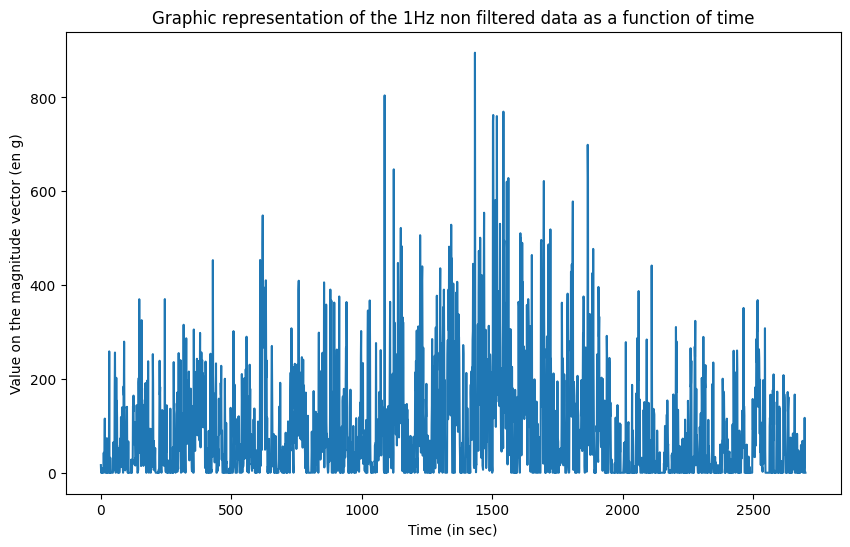

In [ ]:
dom_AC = dom_counts["AC"]
non_dom_AC = non_dom_counts["AC"]

#Display
x_axis_time = np.arange(len(non_dom_AC))


plt.figure(figsize=(10, 6))
plt.plot(x_axis_time,non_dom_AC)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the 1Hz non filtered data as a function of time")   
plt.show()

Mean Activity Count per UL

Dominant mean Activity Counts per sec: 92.40867065990547
Non dominant mean Activity Counts per sec : 46.85880014574167



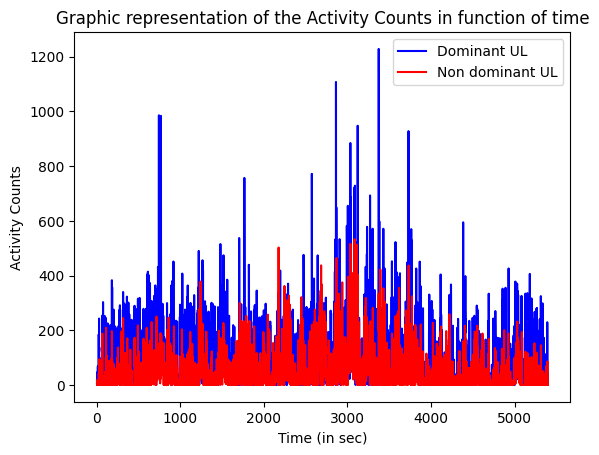

In [5]:
#Mean of AC for 1s
dom_mean_AC = np.sum(dom_AC) / len(dom_AC)
non_dom_mean_AC = np.sum(non_dom_AC) / len(non_dom_AC)

print(f"Dominant mean Activity Counts per sec: {dom_mean_AC}")
print(f"Non dominant mean Activity Counts per sec : {non_dom_mean_AC}\n")

#Display : axis definition
x_axis_time = np.arange(len(dom_AC))

#Display : Activity Counts per second in function of time
plt.plot(x_axis_time,dom_AC,'b', label = "Dominant UL")
plt.plot(x_axis_time,non_dom_AC,'r', label = "Non dominant UL")


plt.legend()
plt.xlabel("Time (in sec)")
plt.ylabel("Activity Counts")
plt.title(f"Graphic representation of the Activity Counts in function of time")
plt.show()

In line with the average AC values in the article:

Araneda, R., Ebner-Karestinos, D., Paradis, J., Klöcker, A., Saussez, G., Demas, J., Bailly, R., Bouvier, S., Carton de Tournai, A., Herman, E., Souki, A., Le Gal, G., Nowak, E., Sizonenko, S. V., Newman, C. J., Dinomais, M., Riquelme, I., Guzzetta, A., Brochard, S., & Bleyenheuft, Y. (2024). Changes Induced by Early Hand-Arm Bimanual Intensive Therapy Including Lower Extremities in Young Children With Unilateral Cerebral Palsy: A Randomized Clinical Trial. JAMA pediatrics, 178(1), 19–28. https://doi.org/10.1001/jamapediatrics.2023.4809

Where mean dominant AC = 43.4 and non dominant AC = 27.7

Use ratio : comparing Activity Counts of the non dominant UL to the Activity Counts of the dominant UL

In [13]:
"""*******************With Active duration************************"""

#Active duration
dom_AD = np.sum(dom_counts["AC"] > 0.0) 
non_dom_AD = np.sum(non_dom_counts["AC"] > 0.0)

#Use ratio with active duration
use_ratio_time = non_dom_AD / dom_AD
print(f"use ratio : {use_ratio_time}")



"""********************* A FINIR *************************"""
"""*******************With Use Ratio************************"""


#Mean Use Ratio
mean_UR = non_dom_mean_AC / dom_mean_AC
print(f"Mean Use Ratio : {mean_UR}")

dom_use_ratio = []

#Use Ratio per sec with Activity counts
use_ratio= []
for idx_sec in range(len(dom_AC)):
  if (non_dom_AC[idx_sec] == 0) & (dom_AC[idx_sec] != 0) :
    dom_use_ratio.append(dom_AC[idx_sec])
  else:
    use_ratio.append(0)

mean_use_ratio = sum(dom_use_ratio) / sum(dom_AC)

print(mean_use_ratio)# sum(the non dominant AC if the other UL is not active) / sum(total non dominant AC)


use ratio : 0.8424129062426935
Mean Use Ratio : 0.5070822879618903
0.1122020052440811


Gardas, S. S., Lysaght, C., McMillan, A. G., Kantak, S., Willson, J. D., Patterson, C. G., & Surkar, S. M. (2023). Bimanual Movement Characteristics and Real-World Performance Following Hand-Arm Bimanual Intensive Therapy in Children with Unilateral Cerebral Palsy. Behavioral sciences (Basel, Switzerland), 13(8), 681. https://doi.org/10.3390/bs13080681

Where mean UR = 0.90 along 5 days (st deviation = 0.06) (0.89 < day value < 0.92)

Seems similar to article:

Hoyt CR, Van AN, Ortega M, et al. (2019). Detection of Pediatric Upper Extremity Motor Activity and Deficits With Accelerometry. JAMA Netw Open, 2(4):e192970. DOI: 10.1001/jamanetworkopen.2019.2970 

Where not precise values but figures (approximation) 0.6 < UR < 0.9

Magnitude Ratio : Quantification of the intensity of the affected limb during the activity compared to that of the other limb.

Magnitude Ratio (calculated with mean AC): -0.6790819848884025 



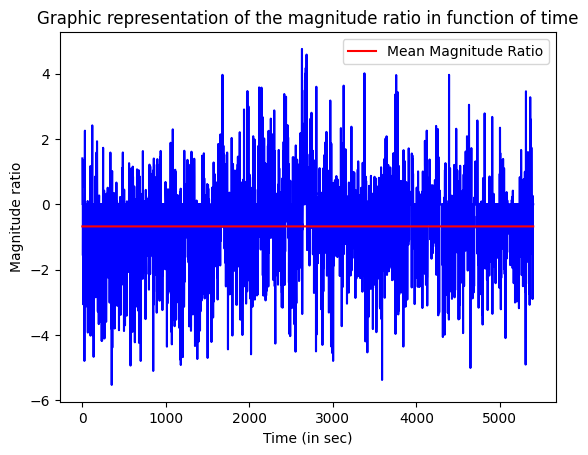

In [6]:
#Mean Magnitude Ratio : ln(non dominant UL / dominant UL)
mean_magnitude_ratio = np.log(non_dom_mean_AC / dom_mean_AC)
print(f"Magnitude Ratio (calculated with mean AC): {mean_magnitude_ratio} \n")

#Magnitude Ratio per second : ln(non dominant UL / dominant UL)
magnitude_ratio = []
for idx_sec in range(len(dom_AC)):
  if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
    magnitude_ratio.append(np.log(non_dom_AC[idx_sec]/dom_AC[idx_sec]))
  else:
    magnitude_ratio.append(0)


#Display : axis definition
x_axis_time = np.arange(len(magnitude_ratio))
display_mean_magnitude_ratio = [mean_magnitude_ratio] * len(x_axis_time)

#Display : Magnitude Ratio per second in function of time
plt.plot(x_axis_time, magnitude_ratio,'b')
plt.plot(x_axis_time,display_mean_magnitude_ratio,'r', label = "Mean Magnitude Ratio")

plt.legend()
plt.xlabel("Time (in sec)")
plt.ylabel("Magnitude ratio")
plt.title(f"Graphic representation of the magnitude ratio in function of time")
plt.show()

In line with the average AC values in the article:

Coker-Bolt P, Downey RJ, Connolly J, Hoover R, Shelton D, Seo NJ. (2017). Exploring the feasibility and use of accelerometers before, during, and after a camp-based CIMT program for children with cerebral palsy. J Pediatr Rehabil Med, 10(1), 27-36. DOI: 10.3233/PRM-170408

Where mean magnitude ratio = -0.95 pre-CIMT and = -0.40 post-CIMT

In line with the average AC values in the article:

Gardas, S. S., Lysaght, C., McMillan, A. G., Kantak, S., Willson, J. D., Patterson, C. G., & Surkar, S. M. (2023). Bimanual Movement Characteristics and Real-World Performance Following Hand-Arm Bimanual Intensive Therapy in Children with Unilateral Cerebral Palsy. Behavioral sciences (Basel, Switzerland), 13(8), 681. https://doi.org/10.3390/bs13080681

Where mean magnitude ratio = -0.56 along 5 days (st deviation = 0.26) ( -0.52 < day value < -0.61 )

Bilateral Magnitude : Quantification of acceleration intensity per second on both limbs.

Total Bilateral Magnitude : 752044.3423504946 

5400
139.26747080564715
139.26747080564715


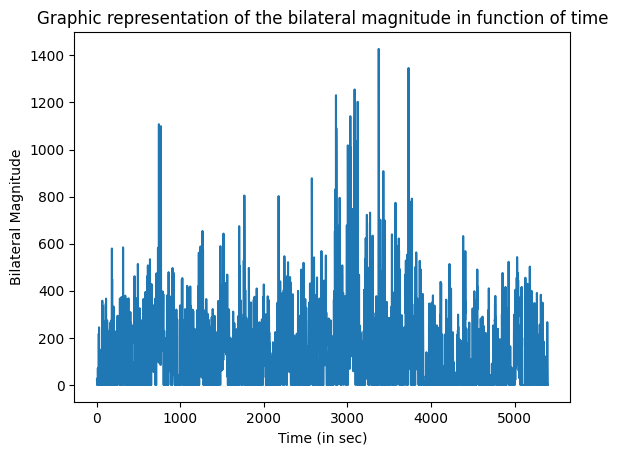

In [ ]:
#Total Bilateral Magnitude : mean_dom_AC + mean_non_dom_AC
total_bilateral_magnitude = np.sum(dom_AC) + np.sum(non_dom_AC)
print(f"Total Bilateral Magnitude : {total_bilateral_magnitude} \n")


#Mean Bilateral Magnitude : total BM / time
mean_bilateral_magnitude = total_bilateral_magnitude / (len(dom_AC) )
print(mean_bilateral_magnitude)

#Bilateral Magnitude per second : dom_AC + non_dom_AC
"""*********Attention : pas besoin que les 2 AC soit différents de 0***********"""
bilateral_magnitude = []
for idx_sec in range(len(dom_AC)):
  if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
    bilateral_magnitude.append(non_dom_AC[idx_sec] + dom_AC[idx_sec])
  else:
    bilateral_magnitude.append(0)

#Display : Bilateral Magnitude  per second in function of time
x_axis_time = np.arange(len(bilateral_magnitude))
plt.plot(x_axis_time, bilateral_magnitude)
plt.xlabel("Time (in sec)")
plt.ylabel("Bilateral Magnitude")
plt.title(f"Graphic representation of the bilateral magnitude in function of time")
plt.show()

Very low compare to the article :

Gardas, S. S., Lysaght, C., McMillan, A. G., Kantak, S., Willson, J. D., Patterson, C. G., & Surkar, S. M. (2023). Bimanual Movement Characteristics and Real-World Performance Following Hand-Arm Bimanual Intensive Therapy in Children with Unilateral Cerebral Palsy. Behavioral sciences (Basel, Switzerland), 13(8), 681. https://doi.org/10.3390/bs13080681

definition of bimanual magnitude in the article : Bilateral magnitude reflects the magnitude of accelerations across both UEs and is calculated by summing the smoothed vector magnitudes of both UEs for each second of activity.
population : 29 children (mean age = 7yo) with unilateral cerebral palsy.

Where mean bilateral magnitude = 167.25 along 5 days (st deviation = 39.83) (161.99 < day value < 173.16)

MAUI : Quantifying the intensity of one member when the other is inactive

In [8]:
#Initializations
dom_MAUI = []
non_dom_MAUI = []

for idx_sec in range(len(dom_AC)):
  #Dominant mouvement intensities when non dominant arm is not moving
  if (non_dom_AC[idx_sec] == 0) & (dom_AC[idx_sec] != 0) :
    dom_MAUI.append(dom_AC[idx_sec])
  #Non dominant mouvement intensities when dominant arm is not moving
  elif (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] == 0) :
    non_dom_MAUI.append(non_dom_AC[idx_sec])

#MAUI = sum(non dominant mvt when dominant UL is not moving) / sum(dominant mvt when non dominant UL is not moving)
maui = np.sum(non_dom_MAUI) / np.sum(dom_MAUI)
print(f" MAUI : {maui}")

#result = 4.9


 MAUI : 0.18939106618157728


Seems similar to article:

Hoyt CR, Van AN, Ortega M, et al. (2019). Detection of Pediatric Upper Extremity Motor Activity and Deficits With Accelerometry. JAMA Netw Open, 2(4):e192970. DOI: 10.1001/jamanetworkopen.2019.2970 

Where not precise values but figures (approximation)

BAUI

In [19]:
#Initializations
dom_BAUI = []
non_dom_BAUI = []

for idx_sec in range(len(dom_AC)):
  #Dominant and non dominant mouvement intensities when the other UL is also moving
  if (non_dom_AC[idx_sec] != 0) & (dom_AC[idx_sec] != 0) :
    dom_BAUI.append(dom_AC[idx_sec])
    non_dom_BAUI.append(non_dom_AC[idx_sec])

#BAUI = sum(non dominant mvt when dominant UL is also moving) / sum(dominant mvt when non dominant UL is also moving)
baui = np.sum(non_dom_BAUI) / np.sum(dom_BAUI)
print(f" BAUI : {baui}")


 BAUI : 0.5472328541298093


Seems similar to article:

Hoyt CR, Van AN, Ortega M, et al. (2019). Detection of Pediatric Upper Extremity Motor Activity and Deficits With Accelerometry. JAMA Netw Open, 2(4):e192970. DOI: 10.1001/jamanetworkopen.2019.2970 

Where not precise values but figures (approximation)